# Gesture LSTM Training — Active Gestures Only

Trains on gestures that are currently in use: **1, 2, 6, 7, 8, 9**.

Model: Bidirectional LSTM with temporal attention, heavy augmentation for the small dataset.

In [1]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random
import copy

In [2]:
# ── Config ──────────────────────────────────────────────────────────
DATA_DIR = 'data'
MODEL_SAVE_PATH = 'models/gesture_lstm2.0.pth'
MAX_SEQ_LENGTH = 10
INPUT_SIZE = 21 * 3          # 21 landmarks × (x, y, z)
HIDDEN_SIZE = 128
NUM_LAYERS = 2
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 120
LABEL_SMOOTHING = 0.1

# Only gestures that are currently in use (from README)
ACTIVE_GESTURES = [1, 2, 6, 7, 8, 9]

# Remap original gesture IDs → contiguous 0..N-1 labels
LABEL_MAP = {orig: new for new, orig in enumerate(sorted(ACTIVE_GESTURES))}
LABEL_NAMES = {v: k for k, v in LABEL_MAP.items()}  # new → orig for display
NUM_CLASSES = len(ACTIVE_GESTURES)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Active gestures: {ACTIVE_GESTURES}')
print(f'Label mapping (original → new): {LABEL_MAP}')
print(f'Number of classes: {NUM_CLASSES}')

Using device: cuda
Active gestures: [1, 2, 6, 7, 8, 9]
Label mapping (original → new): {1: 0, 2: 1, 6: 2, 7: 3, 8: 4, 9: 5}
Number of classes: 6


## Data Loading & Augmentation

With only ~50 samples per gesture, augmentation is critical.

Augmentations applied on-the-fly during training:
- **Gaussian noise** on landmark coords
- **Random time scaling** (stretch/compress the sequence)
- **Spatial scaling** (simulate hand closer/farther)
- **Random frame dropout** (skip a frame, shift the rest)
- **Mirror flip** along x-axis (only applied to non-directional gestures)

In [3]:
# ── Augmentation helpers ────────────────────────────────────────────

def add_noise(seq, sigma=0.01):
    """Add Gaussian noise to landmark coordinates."""
    return seq + np.random.randn(*seq.shape) * sigma


def time_warp(seq, max_seq_length):
    """Randomly stretch or compress the temporal axis."""
    factor = np.random.uniform(0.8, 1.2)
    n_frames = seq.shape[0]
    new_len = max(2, int(n_frames * factor))
    indices = np.linspace(0, n_frames - 1, new_len).astype(int)
    warped = seq[indices]
    return pad_or_truncate(warped, max_seq_length)


def spatial_scale(seq, lo=0.85, hi=1.15):
    """Scale all coordinates (simulates hand distance variation)."""
    factor = np.random.uniform(lo, hi)
    return seq * factor


def frame_dropout(seq, drop_prob=0.1):
    """Randomly drop frames and shift the rest forward."""
    if seq.shape[0] <= 3:
        return seq
    mask = np.random.rand(seq.shape[0]) > drop_prob
    if mask.sum() < 3:
        return seq
    return seq[mask]


def pad_or_truncate(seq, max_seq_length):
    """Pad by repeating last frame or truncate to max_seq_length."""
    if len(seq) > max_seq_length:
        return seq[:max_seq_length]
    elif len(seq) < max_seq_length:
        pad_len = max_seq_length - len(seq)
        padding = np.tile(seq[-1], (pad_len, 1))
        return np.vstack((seq, padding))
    return seq


def augment(seq, max_seq_length):
    """Apply a random combination of augmentations."""
    seq = seq.copy()
    if random.random() < 0.5:
        seq = add_noise(seq, sigma=np.random.uniform(0.005, 0.02))
    if random.random() < 0.4:
        seq = time_warp(seq, max_seq_length)
    if random.random() < 0.4:
        seq = spatial_scale(seq)
    if random.random() < 0.3:
        seq = frame_dropout(seq, drop_prob=0.15)
        seq = pad_or_truncate(seq, max_seq_length)
    return seq

In [4]:
# ── Dataset ─────────────────────────────────────────────────────────

class GestureDataset(Dataset):
    """Loads only active gestures, remaps labels, applies augmentation."""

    def __init__(self, data_dir, max_seq_length, label_map, augment_fn=None):
        self.max_seq_length = max_seq_length
        self.augment_fn = augment_fn
        self.samples = []  # list of (np.array, int)

        for class_name in sorted(os.listdir(data_dir)):
            class_dir = os.path.join(data_dir, class_name)
            if not os.path.isdir(class_dir):
                continue

            orig_label = int(class_name)
            if orig_label not in label_map:
                continue  # ← skip inactive gestures

            new_label = label_map[orig_label]

            for file in sorted(os.listdir(class_dir)):
                if not file.endswith('.json'):
                    continue
                with open(os.path.join(class_dir, file), 'r') as f:
                    frames = json.load(f)
                if not frames:
                    continue

                sequence = []
                for frame in frames:
                    coords = []
                    for lm in frame:
                        coords.extend([lm['x'], lm['y'], lm['z']])
                    sequence.append(coords)

                seq_array = np.array(sequence, dtype=np.float32)
                seq_array = pad_or_truncate(seq_array, max_seq_length)
                self.samples.append((seq_array, new_label))

        print(f'Loaded {len(self.samples)} samples across '
              f'{len(set(s[1] for s in self.samples))} classes')
        # per-class counts
        from collections import Counter
        counts = Counter(s[1] for s in self.samples)
        for new_lbl in sorted(counts):
            orig_lbl = {v: k for k, v in label_map.items()}[new_lbl]
            print(f'  Gesture {orig_lbl} → label {new_lbl}: {counts[new_lbl]} samples')

    def get_labels(self):
        """Return all labels (for stratified splitting)."""
        return [s[1] for s in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, label = self.samples[idx]
        if self.augment_fn is not None:
            seq = self.augment_fn(seq, self.max_seq_length)
        return torch.tensor(seq, dtype=torch.float32), label

In [5]:
# Load the full dataset (no augmentation yet — that's toggled per split)
full_dataset = GestureDataset(DATA_DIR, MAX_SEQ_LENGTH, LABEL_MAP)

Loaded 304 samples across 6 classes
  Gesture 1 → label 0: 51 samples
  Gesture 2 → label 1: 50 samples
  Gesture 6 → label 2: 51 samples
  Gesture 7 → label 3: 51 samples
  Gesture 8 → label 4: 51 samples
  Gesture 9 → label 5: 50 samples


## Model

**Bidirectional LSTM + Temporal Attention**

Why this over the original single-direction, last-hidden approach:
- Bidirectional lets the model see the full gesture arc from both ends — useful since the *ending* shape of gesture 1 ("to the right") may look like the *start* of gesture 2 ("to the left").
- Attention over all timesteps lets the model focus on the *discriminative* part of the motion (e.g. the mid-gesture peak) instead of relying solely on the final frame.
- Layer normalization + dropout after every stage to prevent overfitting on ~300 samples.

In [6]:
class TemporalAttention(nn.Module):
    """Learned attention over LSTM timestep outputs."""

    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1, bias=False),
        )

    def forward(self, lstm_out):
        # lstm_out: (batch, seq_len, hidden_dim)
        scores = self.attn(lstm_out)          # (batch, seq_len, 1)
        weights = torch.softmax(scores, dim=1)
        context = (lstm_out * weights).sum(dim=1)  # (batch, hidden_dim)
        return context, weights.squeeze(-1)


class GestureLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.4):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Input projection + normalization
        self.input_proj = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
        )

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )

        self.layer_norm = nn.LayerNorm(hidden_size * 2)

        # Attention over time
        self.attention = TemporalAttention(hidden_size * 2)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = self.input_proj(x)              # (batch, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)          # (batch, seq_len, hidden_size*2)
        lstm_out = self.layer_norm(lstm_out)
        context, attn_w = self.attention(lstm_out)  # (batch, hidden_size*2)
        logits = self.classifier(context)   # (batch, num_classes)
        return logits


# Quick parameter count
_m = GestureLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES)
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')
del _m

Model parameters: 735,110


## Training with Stratified K-Fold Cross-Validation

With ~50 samples per class, a single random 80/20 split is unreliable. We use **5-fold stratified CV** to get a trustworthy accuracy estimate, then retrain on the full data for the final model.

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(seqs)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * seqs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += seqs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        logits = model(seqs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * seqs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += seqs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

In [8]:
# ── Stratified 5-Fold CV ───────────────────────────────────────────
all_labels_np = np.array(full_dataset.get_labels())
all_indices = np.arange(len(full_dataset))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_indices, all_labels_np)):
    print(f'\n{"="*50}')
    print(f'Fold {fold + 1}/5')
    print(f'{"="*50}')

    # Build fold-specific datasets
    train_ds = copy.copy(full_dataset)
    train_ds.samples = [full_dataset.samples[i] for i in train_idx]
    train_ds.augment_fn = augment  # augmentation ON for training

    val_ds = copy.copy(full_dataset)
    val_ds.samples = [full_dataset.samples[i] for i in val_idx]
    val_ds.augment_fn = None  # augmentation OFF for validation

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    # Fresh model per fold
    model = GestureLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                                  weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0.0
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device)
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 20 == 0:
            print(f'  Epoch {epoch+1:3d}  '
                  f'train_loss={train_loss:.4f}  train_acc={train_acc:.3f}  '
                  f'val_loss={val_loss:.4f}  val_acc={val_acc:.3f}')

    # Evaluate best model on this fold's validation set
    model.load_state_dict(best_state)
    _, val_acc, preds, labels = evaluate(model, val_loader, criterion, device)
    fold_results.append(val_acc)
    print(f'\n  ► Fold {fold+1} best val accuracy: {val_acc:.3f}')

print(f'\n{"="*50}')
print(f'Cross-validation accuracy: {np.mean(fold_results):.3f} ± {np.std(fold_results):.3f}')
print(f'{"="*50}')


Fold 1/5
  Epoch  20  train_loss=0.5349  train_acc=0.963  val_loss=0.5554  val_acc=0.951
  Epoch  40  train_loss=0.5078  train_acc=0.979  val_loss=0.5450  val_acc=0.967
  Epoch  60  train_loss=0.4582  train_acc=0.992  val_loss=0.5134  val_acc=0.967
  Epoch  80  train_loss=0.4369  train_acc=0.996  val_loss=0.4543  val_acc=0.984
  Epoch 100  train_loss=0.4314  train_acc=1.000  val_loss=0.4651  val_acc=0.984
  Epoch 120  train_loss=0.4345  train_acc=1.000  val_loss=0.4584  val_acc=0.967

  ► Fold 1 best val accuracy: 0.984

Fold 2/5
  Epoch  20  train_loss=0.5560  train_acc=0.934  val_loss=0.8147  val_acc=0.820
  Epoch  40  train_loss=0.5834  train_acc=0.922  val_loss=0.5210  val_acc=0.934
  Epoch  60  train_loss=0.4563  train_acc=0.992  val_loss=0.4681  val_acc=0.984
  Epoch  80  train_loss=0.4330  train_acc=1.000  val_loss=0.4214  val_acc=1.000
  Epoch 100  train_loss=0.4306  train_acc=1.000  val_loss=0.4212  val_acc=1.000
  Epoch 120  train_loss=0.4313  train_acc=1.000  val_loss=0.421

## Final Model: Train on All Data

In [9]:
# ── Retrain on the full dataset ────────────────────────────────────
full_train_ds = copy.copy(full_dataset)
full_train_ds.augment_fn = augment

train_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE, shuffle=True)

model = GestureLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                              weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('Training final model on all data...')
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device)
    scheduler.step()

    if (epoch + 1) % 20 == 0:
        print(f'  Epoch {epoch+1:3d}  loss={train_loss:.4f}  acc={train_acc:.3f}')

os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'label_map': LABEL_MAP,
    'label_names': LABEL_NAMES,
    'active_gestures': ACTIVE_GESTURES,
    'input_size': INPUT_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'num_classes': NUM_CLASSES,
    'max_seq_length': MAX_SEQ_LENGTH,
}, MODEL_SAVE_PATH)
print(f'\nModel saved to {MODEL_SAVE_PATH}')

Training final model on all data...
  Epoch  20  loss=0.5924  acc=0.931
  Epoch  40  loss=0.4705  acc=0.990
  Epoch  60  loss=0.4477  acc=0.993
  Epoch  80  loss=0.4309  acc=1.000
  Epoch 100  loss=0.4300  acc=1.000
  Epoch 120  loss=0.4301  acc=1.000

Model saved to models/gesture_lstm2.0.pth


## Evaluation: Hold-out Confusion Matrix

Run this on a quick 80/20 split just to get a visual confusion matrix and per-class report.

Test Accuracy: 98.36%

              precision    recall  f1-score   support

   Gesture 1       1.00      1.00      1.00        10
   Gesture 2       1.00      0.90      0.95        10
   Gesture 6       1.00      1.00      1.00        10
   Gesture 7       0.91      1.00      0.95        10
   Gesture 8       1.00      1.00      1.00        11
   Gesture 9       1.00      1.00      1.00        10

    accuracy                           0.98        61
   macro avg       0.98      0.98      0.98        61
weighted avg       0.99      0.98      0.98        61



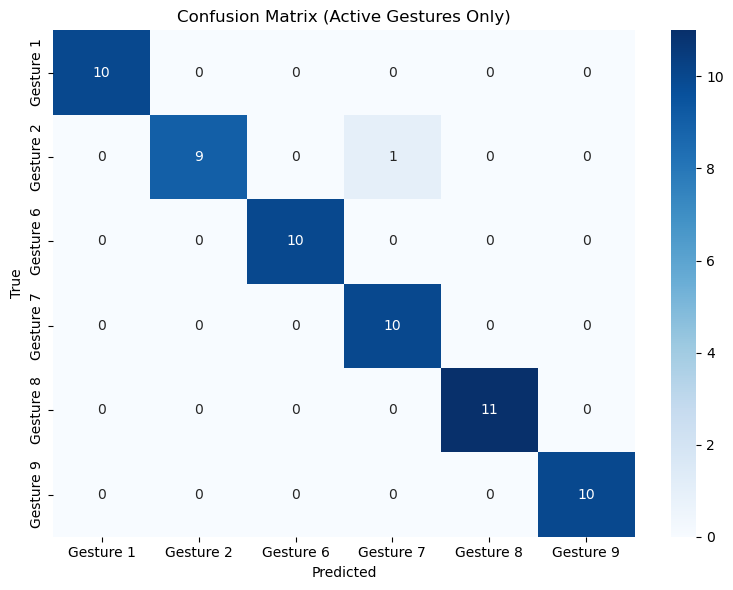

In [10]:
# ── Quick stratified 80/20 for confusion matrix ────────────────────
from sklearn.model_selection import train_test_split

indices = np.arange(len(full_dataset))
labels_arr = np.array(full_dataset.get_labels())
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, stratify=labels_arr, random_state=0)

test_ds = copy.copy(full_dataset)
test_ds.samples = [full_dataset.samples[i] for i in test_idx]
test_ds.augment_fn = None

train_ds = copy.copy(full_dataset)
train_ds.samples = [full_dataset.samples[i] for i in train_idx]
train_ds.augment_fn = augment

tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
te_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

eval_model = GestureLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(eval_model.parameters(), lr=LEARNING_RATE,
                               weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    train_one_epoch(eval_model, tr_loader, criterion, optimizer, device)
    scheduler.step()

_, test_acc, all_preds, all_labels = evaluate(
    eval_model, te_loader, criterion, device)
print(f'Test Accuracy: {test_acc*100:.2f}%\n')

# Class names for the report
target_names = [f'Gesture {LABEL_NAMES[i]}' for i in range(NUM_CLASSES)]
print(classification_report(all_labels, all_preds, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Active Gestures Only)')
plt.tight_layout()
plt.show()

In [ ]:
# ── How to load the model for inference ────────────────────────────
# checkpoint = torch.load(MODEL_SAVE_PATH)
# model = GestureLSTM(
#     checkpoint['input_size'],
#     checkpoint['hidden_size'],
#     checkpoint['num_layers'],
#     checkpoint['num_classes'],
# )
# model.load_state_dict(checkpoint['model_state_dict'])
# model.eval()
# label_names = checkpoint['label_names']  # {0: 1, 1: 2, 2: 6, ...}